# Deploy a CNN to the OpenMV N6 — Step by Step

This notebook takes a small image classifier all the way from **training on your laptop** to
**running live on the OpenMV N6 camera** using its Neural-ART NPU.

**Example task:** Ants vs Bees (a ~400-image public dataset, no login needed). Swap in your own
images later — the pipeline is identical.

**The pipeline:** `train → ONNX → int8 → ST Edge AI compile → SD card → live on the N6`

### N6 rules baked into this notebook (learned the hard way)
1. **int8 only** — a float model runs 100% on the CPU (pointless). Quantization is what puts it on the NPU.
2. **NHWC input** — the firmware reads the *last* dimension as channels; ONNX is NCHW, so we insert a transpose.
3. **Model must be ≈≥1 MB** — the N6's runtime loader **rejects tiny models** (a firmware quirk). Ours is ~2 MB by design.
4. **Use ReLU, not tanh** — ReLU is NPU-native; tanh falls back to the CPU.
5. **Export at the resolution you trained at** — a mismatch silently kills accuracy.
6. **Camera resolution is independent of the model input** — the firmware resizes each frame, so a 96×96 model runs on a VGA camera.

## 0. What you need

- **OpenMV N6** board + a **microSD card**.
- **OpenMV IDE** installed (it bundles the `stedgeai` compiler we use).
- The **openmv firmware repo** cloned (we only need two config files from it: `lib/stai/scripts/neuralart.json` and `stm32n6.mpool`).
- A Python env with `torch onnx onnxruntime pillow numpy`.

Run the next cell to install the Python packages.

In [16]:
import sys
!{sys.executable} -m pip install -q torch onnx onnxruntime pillow numpy

### Configure paths (edit these for your machine)

In [17]:
import os

# The ST Edge AI compiler shipped with the OpenMV IDE:
STEDGEAI  = os.path.expanduser('~/openmvide/share/qtcreator/stedgeai/Utilities/linux/stedgeai')
# The NPU profile from the openmv firmware repo (keep neuralart.json next to stm32n6.mpool):
OPENMV_REPO = os.path.expanduser('~/developer_dq/openmv')
NEURALART = f'{OPENMV_REPO}/lib/stai/scripts/neuralart.json'
# A working folder for this tutorial:
WORK = os.path.expanduser('~/n6_tutorial'); os.makedirs(WORK, exist_ok=True); os.chdir(WORK)

assert os.path.exists(STEDGEAI), 'Edit STEDGEAI to your OpenMV IDE install path'
assert os.path.exists(NEURALART), 'Edit OPENMV_REPO to your cloned openmv repo'
import subprocess; print(subprocess.run([STEDGEAI,'--version'],capture_output=True,text=True).stdout.strip())

ST Edge AI Core v4.0.0-20500 359356bb0
   STM32CubeAI 12.0.0-RC4


## 1. Get the dataset (~ants & bees)

A small, public, no-login dataset from the official PyTorch tutorial. Two classes.
We use `train/` to train and `val/` (~150 images) to evaluate and to **calibrate** the int8 model.

In [18]:
import urllib.request, zipfile, os, glob
URL = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
if not os.path.exists('hymenoptera_data'):
    print('downloading...'); urllib.request.urlretrieve(URL, 'data.zip')
    zipfile.ZipFile('data.zip').extractall('.'); print('done')
DATA = 'hymenoptera_data'
CLASSES = ['ants', 'bees']
for split in ['train','val']:
    counts = {c: len(glob.glob(f'{DATA}/{split}/{c}/*.jpg')) for c in CLASSES}
    print(split, counts, 'total', sum(counts.values()))

train {'ants': 122, 'bees': 121} total 243
val {'ants': 70, 'bees': 83} total 153


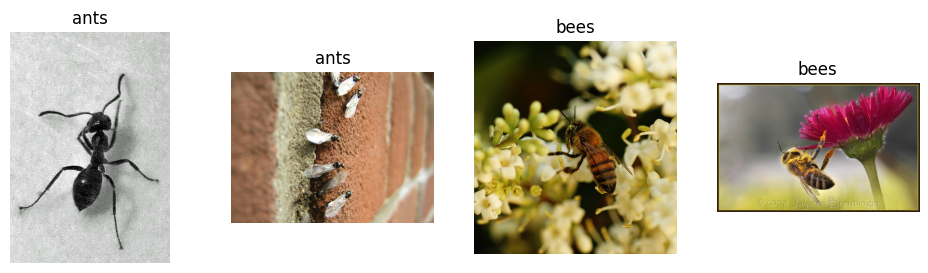

In [19]:
# peek at a few images
import matplotlib.pyplot as plt; from PIL import Image; import glob
fig,ax=plt.subplots(1,4,figsize=(12,3))
for a,f in zip(ax, glob.glob(f'{DATA}/train/ants/*.jpg')[:2]+glob.glob(f'{DATA}/train/bees/*.jpg')[:2]):
    a.imshow(Image.open(f)); a.set_title(os.path.basename(os.path.dirname(f))); a.axis('off')
plt.show()

## 2. Define and train the model

A compact CNN, **deliberately sized ~2 MB** so it clears the N6's ~1 MB load floor, using **ReLU** so
every layer maps to the NPU, and a **96×96** input so it's fast and its activations fit on-chip.

> This exact architecture was verified to load and run in **~6 ms** on a real N6.

Training from scratch on a few hundred images won't be perfect — that's fine, the goal is the *pipeline*.
To improve accuracy later: more data, more epochs, or transfer learning.

In [20]:
import torch, torch.nn as nn
S = 96                       # input size (train AND export at this size)
NC = len(CLASSES)

class Net(nn.Module):
    def __init__(self, nc):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3,32,3,2,1),  nn.ReLU(),   # 96->48
            nn.Conv2d(32,64,3,2,1), nn.ReLU(),   # 48->24
            nn.Conv2d(64,128,3,2,1),nn.ReLU(),   # 24->12
            nn.Conv2d(128,128,3,2,1),nn.ReLU())  # 12->6
        self.head = nn.Sequential(nn.Linear(6*6*128,384), nn.ReLU(), nn.Linear(384,nc))
    def forward(self,x): return self.head(self.f(x).reshape(x.size(0),-1))

net = Net(NC)
print('parameters:', sum(p.numel() for p in net.parameters()), '(~', round(sum(p.numel() for p in net.parameters())/1e6,1),'M -> ~2 MB int8, clears the load floor)')

parameters: 2011458 (~ 2.0 M -> ~2 MB int8, clears the load floor)


In [21]:
# data loaders with light augmentation. Preprocessing = resize to 96, /255 (ToTensor). REMEMBER this recipe.
import torch, glob, random
from PIL import Image
import numpy as np

def load(split):
    xs, ys = [], []
    for ci,c in enumerate(CLASSES):
        for f in glob.glob(f'{DATA}/{split}/{c}/*.jpg'):
            im = Image.open(f).convert('RGB').resize((S,S))
            xs.append(np.asarray(im,np.float32)/255.0); ys.append(ci)
    x = torch.tensor(np.array(xs)).permute(0,3,1,2)   # NCHW [0,1]
    return x, torch.tensor(ys)

xtr,ytr = load('train'); xva,yva = load('val')
print('train', xtr.shape, 'val', xva.shape)

train torch.Size([243, 3, 96, 96]) val torch.Size([153, 3, 96, 96])


In [22]:
# quick training loop
dev = 'cuda' if torch.cuda.is_available() else 'cpu'; net=net.to(dev)
opt = torch.optim.Adam(net.parameters(), 1e-3)
lossf = nn.CrossEntropyLoss()
xtr_d,ytr_d,xva_d,yva_d = xtr.to(dev),ytr.to(dev),xva.to(dev),yva.to(dev)
for ep in range(20):
    net.train(); perm=torch.randperm(len(xtr_d))
    for i in range(0,len(perm),32):
        idx=perm[i:i+32]; xb=xtr_d[idx]
        xb = xb + 0.02*torch.randn_like(xb)                # tiny noise aug
        if random.random()<0.5: xb=torch.flip(xb,[3])      # horizontal flip
        opt.zero_grad(); loss=lossf(net(xb), ytr_d[idx]); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): acc=(net(xva_d).argmax(1)==yva_d).float().mean().item()
    if ep%5==0 or ep==19: print(f'epoch {ep:2d}  val_acc {acc:.2f}')
net=net.cpu().eval(); torch.save(net.state_dict(),'clf.pth'); print('saved clf.pth')

epoch  0  val_acc 0.54
epoch  5  val_acc 0.56
epoch 10  val_acc 0.70
epoch 15  val_acc 0.65
epoch 19  val_acc 0.63
saved clf.pth


## 3. Export to ONNX and fix the layout (NHWC)

ONNX is **NCHW** `(1,3,96,96)`; the N6 firmware needs **NHWC** `(1,96,96,3)`.
We export, then insert a `Transpose` at the input. The math is unchanged — we verify that.

In [24]:
import torch, onnx
from onnx import helper, TensorProto

net.eval()
dummy=(torch.zeros(1,3,S,S),)
kw=dict(input_names=['x'],output_names=['y'],opset_version=13)
try:  # torch>=2.5 accepts dynamo=; older torch does not
    torch.onnx.export(net,dummy,'clf.onnx',dynamo=False,**kw)
except TypeError:
    torch.onnx.export(net,dummy,'clf.onnx',**kw)

m=onnx.load('clf.onnx'); g=m.graph; old=g.input[0]; nm=old.name
n,c,h,w=[d.dim_value for d in old.type.tensor_type.shape.dim]
g.input.remove(old)
g.input.insert(0, helper.make_tensor_value_info('x_nhwc',TensorProto.FLOAT,[n,h,w,c]))
g.node.insert(0, helper.make_node('Transpose',['x_nhwc'],[nm],perm=[0,3,1,2],name='nhwc2nchw'))
onnx.checker.check_model(m); onnx.save(m,'clf_nhwc.onnx')
print('NHWC input:', (n,h,w,c))

============= Diagnostic Run torch.onnx.export version 2.0.0+cu117 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

NHWC input: (1, 96, 96, 3)


In [25]:
# verify the transpose didn't change the math
import numpy as np, onnxruntime as ort
a=np.random.rand(1,3,S,S).astype(np.float32)
o1=ort.InferenceSession('clf.onnx').run(None,{'x':a})[0]
o2=ort.InferenceSession('clf_nhwc.onnx').run(None,{'x_nhwc':a.transpose(0,2,3,1).copy()})[0]
print('match:', np.allclose(o1,o2,atol=1e-5))

match: True


## 4. Quantize to int8

The NPU only runs int8. Calibration uses **real images preprocessed exactly like training** (resize 96, /255).
Then we check the int8 model still classifies as well as the float one.

In [26]:
import glob, numpy as np
from PIL import Image
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType, QuantFormat

def load_nhwc(path):
    im=Image.open(path).convert('RGB').resize((S,S))
    return (np.asarray(im,np.float32)/255.0)[None]     # (1,96,96,3)

calib = sorted(glob.glob(f'{DATA}/val/*/*.jpg'))       # ~150 real images
print('calibration images:', len(calib))
class Reader(CalibrationDataReader):
    def __init__(s): s.it=iter(calib)
    def get_next(s):
        f=next(s.it,None); return None if f is None else {'x_nhwc': load_nhwc(f)}
quantize_static('clf_nhwc.onnx','clf_int8.onnx',Reader(),quant_format=QuantFormat.QDQ,
                activation_type=QuantType.QInt8, weight_type=QuantType.QInt8, per_channel=True)
print('saved clf_int8.onnx')

calibration images: 153


saved clf_int8.onnx


In [27]:
# float vs int8 accuracy on the val set
import onnxruntime as ort, glob, numpy as np
fs=ort.InferenceSession('clf_nhwc.onnx'); qs=ort.InferenceSession('clf_int8.onnx')
fok=qok=tot=0
for ci,c in enumerate(CLASSES):
    for f in glob.glob(f'{DATA}/val/{c}/*.jpg'):
        x=load_nhwc(f); tot+=1
        fok += fs.run(None,{'x_nhwc':x})[0].argmax()==ci
        qok += qs.run(None,{'x_nhwc':x})[0].argmax()==ci
print(f'val accuracy   float: {fok/tot:.2f}   int8: {qok/tot:.2f}')

val accuracy   float: 0.63   int8: 0.63


## 5. Compile for the NPU with ST Edge AI

`analyze` checks it fits and shows NPU vs CPU placement (no board needed); `generate` makes the loadable `.bin`.
We confirm: **weights ≥ ~1 MB** (so it loads), **SW epochs = 0** (fully on NPU), activations fit on-chip.

In [28]:
import subprocess
def ste(cmd):
    r=subprocess.run([STEDGEAI]+cmd, capture_output=True, text=True)
    return r.stdout + r.stderr
out = ste(['analyze','--model','clf_int8.onnx','--type','onnx','--target','stm32n6',
           '--st-neural-art', f'default@{NEURALART}','--workspace','ws','--output','out'])
for line in out.splitlines():
    if any(k in line for k in ['weights (ro)','hyperRAM','software (SW)','hardware (HW','activations (rw)']):
        print(line.strip())

weights (ro)       :   2,010,726 B (1.92 MiB) (1 segment) / -6,035,106(-75.0%) vs float model
activations (rw)   :   110,592 B (108.00 KiB) (1 segment) *
hyperRAM   [0x92000000 - 0x93000000]:          0  B /     16.000 MB  (  0.00 % used) -- weights:          0  B (  0.00 % used)  activations:          0  B (  0.00 % used)
>> pure software (SW) epochs                         0
>> pure hardware (HW or EC) epochs                   9  (implemented in 1 epoch controller blobs/meta epochs)


In [29]:
out = ste(['generate','--model','clf_int8.onnx','--type','onnx','--target','stm32n6','--relocatable',
           '--st-neural-art', f'default@{NEURALART}','--workspace','ws','--output','out'])
import os
binp='out/network_rel.bin'; sz=os.path.getsize(binp)
print(f'network_rel.bin: {sz} bytes  ({sz/1e6:.2f} MB)')
assert sz > 1_000_000, 'Binary < 1 MB may not load on the N6 — make the model bigger.'
print('OK: above the ~1 MB load floor.')

network_rel.bin: 2026864 bytes  (2.03 MB)
OK: above the ~1 MB load floor.


## 6. Put it on the SD card

1. Copy **`~/n6_tutorial/out/network_rel.bin`** onto the SD card as **`clf.bin`**.
2. Create a labels file next to it. Run the next cell to write it, then copy it too.

Easiest: pop the SD card into your laptop and drag both files on. (Or copy over USB with `omv_put.py`.)

In [15]:
with open('clf.txt','w') as f: f.write('\n'.join(CLASSES)+'\n')
print('wrote clf.txt with labels:', CLASSES)
print('Copy these two files to the SD card as /sdcard/clf.bin and /sdcard/clf.txt :')
print('  ', os.path.abspath('out/network_rel.bin'), ' -> /sdcard/clf.bin')
print('  ', os.path.abspath('clf.txt'), '        -> /sdcard/clf.txt')

wrote clf.txt with labels: ['ants', 'bees']
Copy these two files to the SD card as /sdcard/clf.bin and /sdcard/clf.txt :
   /home/aoqiao/n6_tutorial/out/network_rel.bin  -> /sdcard/clf.bin
   /home/aoqiao/n6_tutorial/clf.txt         -> /sdcard/clf.txt


## 7. Run it LIVE on the N6

This part runs **in the OpenMV IDE**, not in Jupyter. Plug the N6 in, open the IDE, connect,
paste the script below, and press **Run**. Point the camera at a picture of an ant or a bee
(a photo on your phone works) and watch the label update.

```python
# --- paste into the OpenMV IDE and press Run ---
import csi, image, time, ml

csi0 = csi.CSI(); csi0.reset()
csi0.pixformat(csi.RGB565)
csi0.framesize(csi.QVGA)            # camera res is independent of the 96x96 model
csi0.snapshot(time=2000)

m = ml.Model('/sdcard/clf.bin')                       # loads because it's ~2 MB
labels = [l.strip() for l in open('/sdcard/clf.txt')]
clock = time.clock()

while True:
    clock.tick()
    img = csi0.snapshot()
    W, H = img.width(), img.height(); s = min(W, H)    # centre-square crop
    small = image.Image(96, 96, image.RGB565)
    small.draw_image(img, 0, 0, roi=((W-s)//2, (H-s)//2, s, s),
                     x_scale=96/s, y_scale=96/s)        # -> 96x96 (model does /255)
    out = m.predict([small])[0]
    vals = [out[0, i] for i in range(len(labels))]
    k = 0
    for i in range(len(vals)):
        if vals[i] > vals[k]: k = i
    img.draw_string((4, 4), labels[k], color=(255, 0, 0), scale=3)
    print(clock.fps(), labels[k], [round(v, 2) for v in vals])
```

## Appendix — Why each choice (the N6 gotchas)

| Choice | Reason |
|---|---|
| **int8** | The Neural-ART NPU only runs int8; a float model executes 100% on the CPU. |
| **NHWC input** | Firmware reads the last dim as channels; feeding NCHW throws `Expected channels to be 1 or 3`. |
| **Model ≥ ~1 MB** | The N6's runtime loader rejects tiny models with `Failed to load network` (a firmware quirk; a 358 KB model fails, a 1.3 MB identical-architecture one loads). |
| **ReLU, not tanh** | ReLU maps to the NPU; tanh falls back to CPU `SW` epochs. This model reports 0 SW epochs. |
| **Export == train resolution** | A model trained at 96 but exported at another size silently loses accuracy. |
| **Camera res ≠ model input** | `draw_image(..., x_scale, y_scale)` resizes each frame to the model's 96×96; the sensor can run at any resolution. |

**To adapt this to your own task:** replace the `hymenoptera_data` folder with your own
`train/<class>/*.jpg` and `val/<class>/*.jpg`, update `CLASSES`, and re-run every cell.
Keep the model ≥ ~1 MB and use ReLU, and it will deploy the same way.